# 6. Quiz

## 어느 결혼식장에서 피로연의 식수 인원을 올바르게 예측하지 못하여 버려지는 음식으로 고민이 많다고 합니다. 현재까지 진행된 결혼식에 대한 결혼식 참석 인원과 그 중에서 식사를 하는 인원의 데이터가 제공될 때, 아래 각 문항에 대한 코드를 작성하시오.

주의) 사전 작업으로 아래 코드 셀을 먼저 실행하시오

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#CP949오류 해결
import sklearn
sklearn.set_config(display='text')

## 1) QuizData.csv 파일로부터 데이터를 읽어와서 결혼식 참석 인원(total), 식수 인원(reception)을 각각의 변수로 저장하시오.

In [2]:
dataset = pd.read_csv('QuizData.csv')
dataset.head()

,total,reception
0,118,62
1,253,148
2,320,201
3,94,80
4,155,92


In [3]:
X = dataset.iloc[:, : -1].values #결혼식 참석 인원 total
y = dataset.iloc[:, -1].values #식수 인원 reception

In [4]:
X[:5], y[:5]

(array([[118],
        [253],
        [320],
        [ 94],
        [155]]),
 array([ 62, 148, 201,  80,  92]))

## 2) 전체 데이터를 훈련 세트와 테스트 세트로 분리하시오. 이 때 비율은 75 : 25 로 합니다.

(단, random_state = 0 으로 설정)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## 3) 훈련 세트를 이용하여 단순 선형 회귀 (Simple Linear Regression) 모델을 생성하시오.

In [8]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

## 4) 데이터 시각화 (훈련 세트) 코드를 작성하시오.

<function matplotlib.pyplot.show(close=None, block=None)>

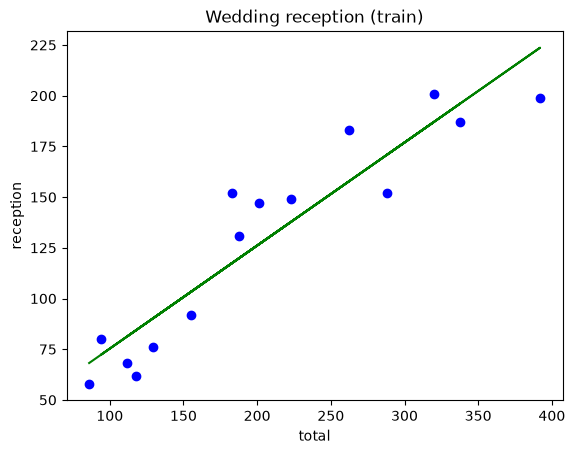

In [14]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, reg.predict(X_train), color='green') #reg.predict(X_train) -> X 값에 대한 y값 반환
plt.title('Wedding reception (train)')
plt.xlabel('total')
plt.ylabel('reception')
plt.show

## 5) 데이터 시각화 (테스트 세트) 코드를 작성하시오.

<function matplotlib.pyplot.show(close=None, block=None)>

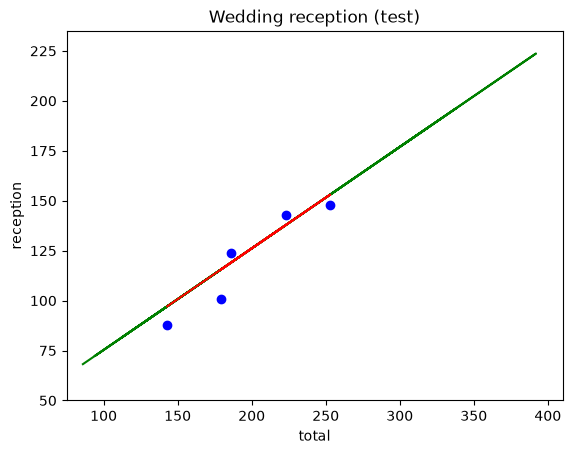

In [20]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_train, reg.predict(X_train), color='green') #훈련시킨 모델 사용이라 보기 편하게 train 그대로 해도 무방하다.
plt.plot(X_test, reg.predict(X_test), color='red') #비교
plt.title('Wedding reception (test)')
plt.xlabel('total')
plt.xlim(75, 410)
plt.ylabel('reception')
plt.ylim(50, 235)
plt.show

## 6) 훈련 세트, 테스트 세트에 대해 각각 모델 평가 점수를 구하시오.

In [21]:
reg.score(X_train, y_train)

0.8707088403321211

In [22]:
reg.score(X_test, y_test)

0.8634953212566615

## 7) 결혼식 참석 인원이 300명일 때 예상되는 식수 인원을 구하시오.

In [31]:
total = 300 #결혼식 참석 인원
y_pred = reg.predict([[total]]) #2차원 배열 사용!!

print(f'결혼식 참석 인원 {total}명에 대한 예상 식수 인원은 {np.around(y_pred[0]).astype(int)}명 입니다.') #np.around -> 반올림
# print(f'결혼식 참석 인원 {total}명에 대한 예상 식수 인원은 {y_pred[0]:.0f}명 입니다.') f-string 문법

결혼식 참석 인원 300명에 대한 예상 식수 인원은 177명 입니다.
